In [40]:
import dorito
from scipy.datasets import ascent

wl = dorito.wavelets.Wavelets(ascent())

In [44]:
wl.distribution.sum() * 0.25837363

Array(0.99958031, dtype=float64)

In [45]:
wl = wl.multiply("approx", 2)
wl = wl.normalise()
wl.approx.sum() + wl.values.sum()

Array(1., dtype=float64)

In [46]:
np.sqrt(0.25837363)

Array(0.50830466, dtype=float64, weak_type=True)

In [3]:
import matplotlib as mpl

import jax

jax.config.update("jax_enable_x64", True)

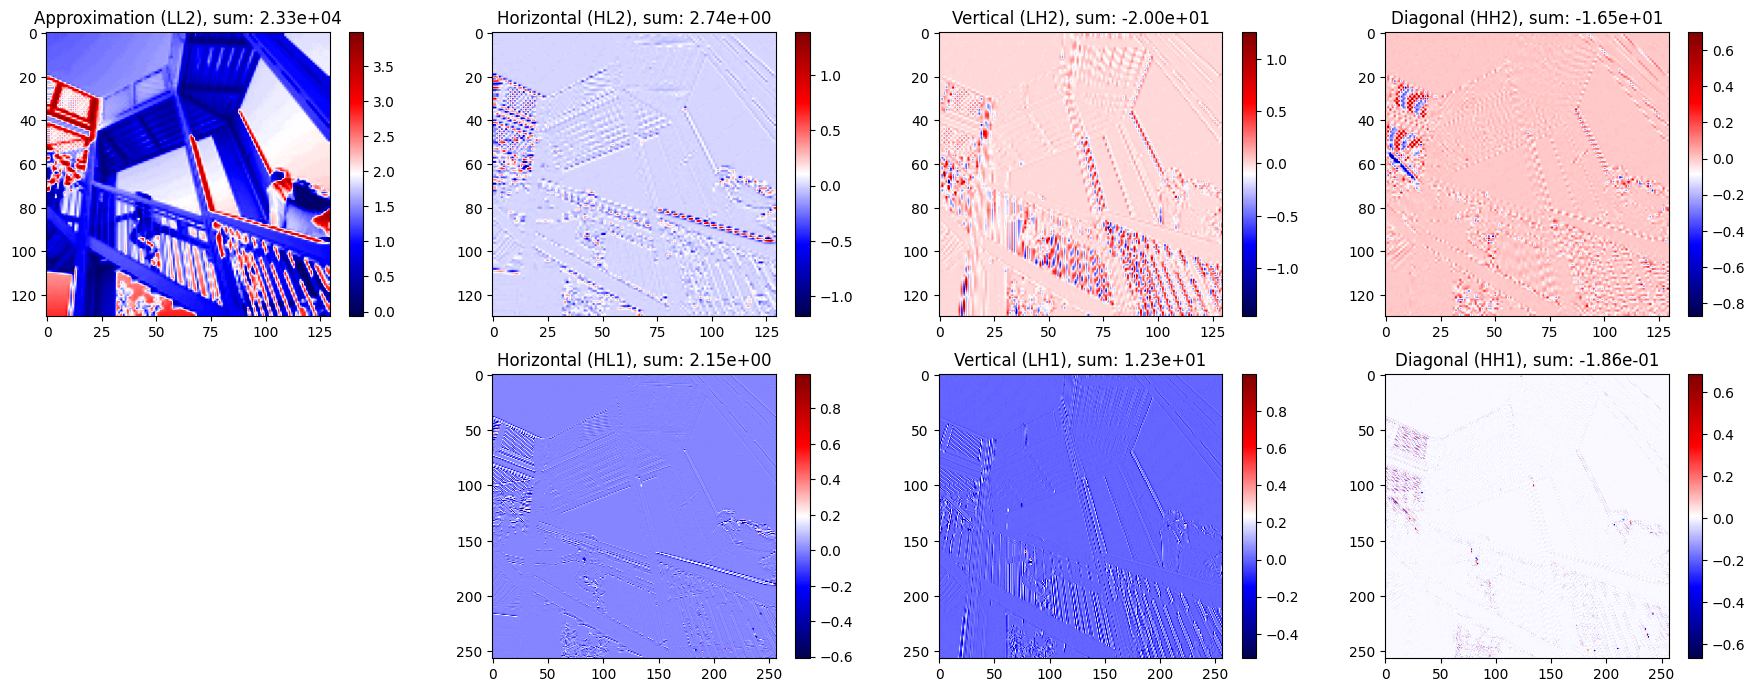

In [82]:
import jax.numpy as np
import jaxwt as jwt
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.datasets import face, ascent

# Load and preprocess the image
# image = np.transpose(ascent(), [1, 0, 2])  # [..., 0]  # Convert to grayscale
image = ascent().astype(np.float32) / 255.0

# Perform 2-level wavelet decomposition using the Haar wavelet
coeffs = jwt.wavedec2(image, wavelet="db2", level=2)


def level2_plot(coeffs):
    # Extract the decomposition coefficients
    ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

    # Plotting corner plot visualization
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    titles = [
        "Approximation (LL2)",
        "Horizontal (HL2)",
        "Vertical (LH2)",
        "Diagonal (HH2)",
        "Horizontal (HL1)",
        "Vertical (LH1)",
        "Diagonal (HH1)",
    ]

    coeff_plots = [ll2, hl2, lh2, hh2, hl1, lh1, hh1]
    positions = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]

    # Plot each coefficient sub-band
    for (i, j), coeff, title in zip(positions, coeff_plots, titles):
        ax = axes[i, j]
        c = ax.imshow(coeff.squeeze(), cmap="seismic")
        ax.set_title(title + f", sum: {coeff.sum():.2e}")
        # ax.axis("off")
        fig.colorbar(
            c,
            ax=ax,
        )

    axes[1, 0].axis("off")  # Hide unused subplot
    plt.tight_layout()
    plt.show()


level2_plot(coeffs)

In [100]:
# stack00 = np.hstack([ll2[0], hl2[0]])
stack00 = np.hstack([np.zeros_like(ll2)[0], hl2[0]])


stack01 = np.hstack([lh2[0], hh2[0]])

stack0 = np.vstack([stack00, stack01])

stack10 = np.hstack([stack0, np.pad(hl1[0], ((0, 3), (0, 3)))])

stack11 = np.hstack(
    [np.pad(lh1[0], ((0, 3), (0, 3))), np.pad(hh1[0], ((0, 3), (0, 3)))]
)

stack = np.vstack([stack10, stack11])

In [101]:
hl1_padded = np.pad(
    hl1,
    ((0, 0), (0, 3), (0, 3)),
    # mode="constant",
    # constant_values=0,
)
hl1_padded.shape

# def pad_to()

(1, 260, 260)

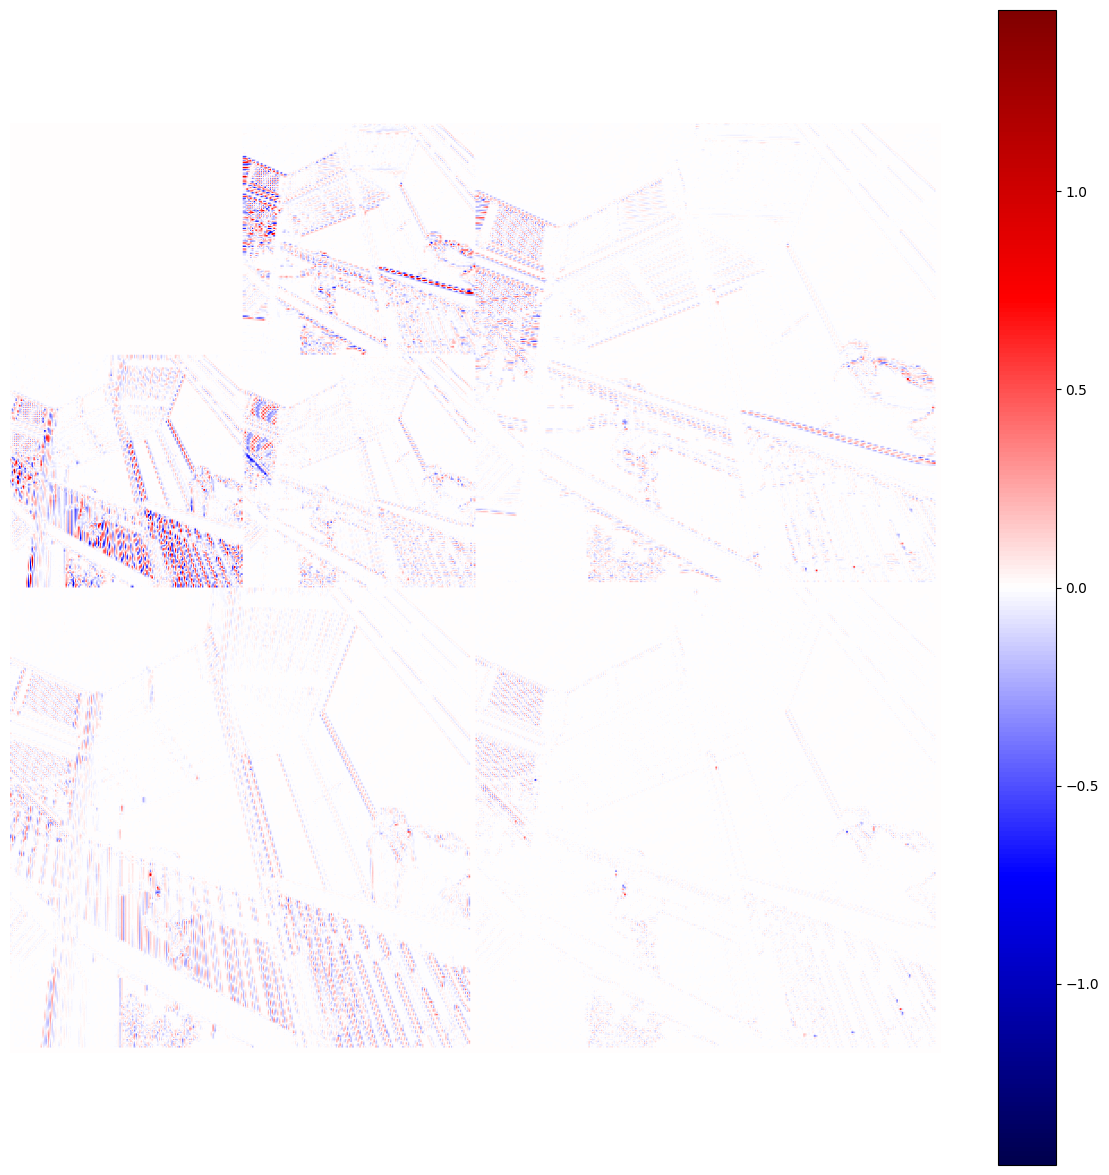

(520, 520)


In [103]:
plt.figure(figsize=(15, 15))
plt.imshow(stack.squeeze(), cmap="seismic", norm=mpl.colors.CenteredNorm(0))
plt.colorbar()
plt.axis("off")
plt.show()

print(stack.shape)

In [105]:
for wl in [ll2, hl2, lh2, hh2, hl1, lh1, hh1]:
    print(wl.shape, wl.sum())

(1, 130, 130) 23255.21
(1, 130, 130) 2.7396417
(1, 130, 130) -20.00638
(1, 130, 130) -16.536484
(1, 257, 257) 2.147571
(1, 257, 257) 12.346356
(1, 257, 257) -0.18555701


In [111]:
(image / 4).sum()

22482.67

0.04772009788695772


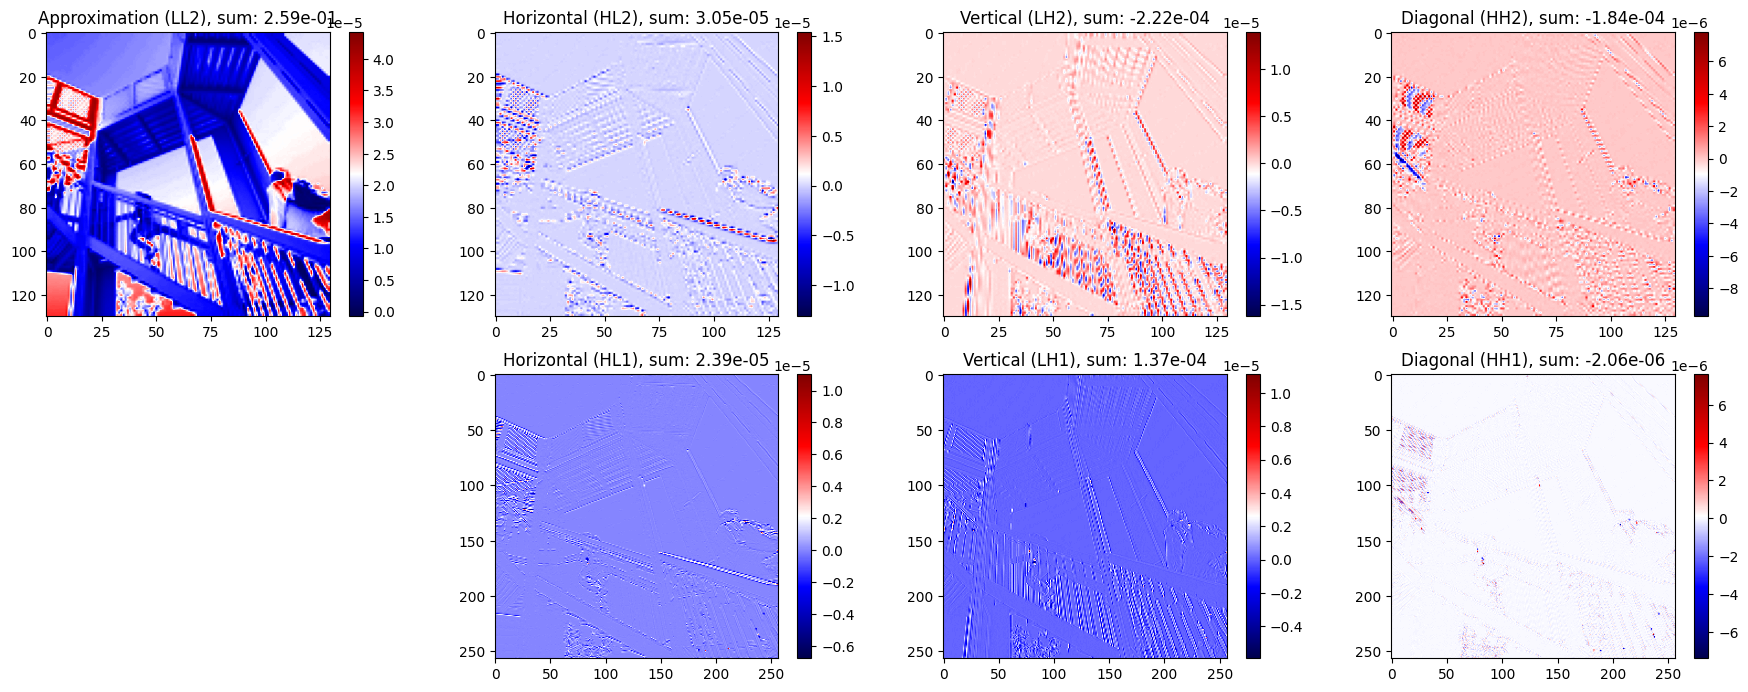

0.044538102542935075


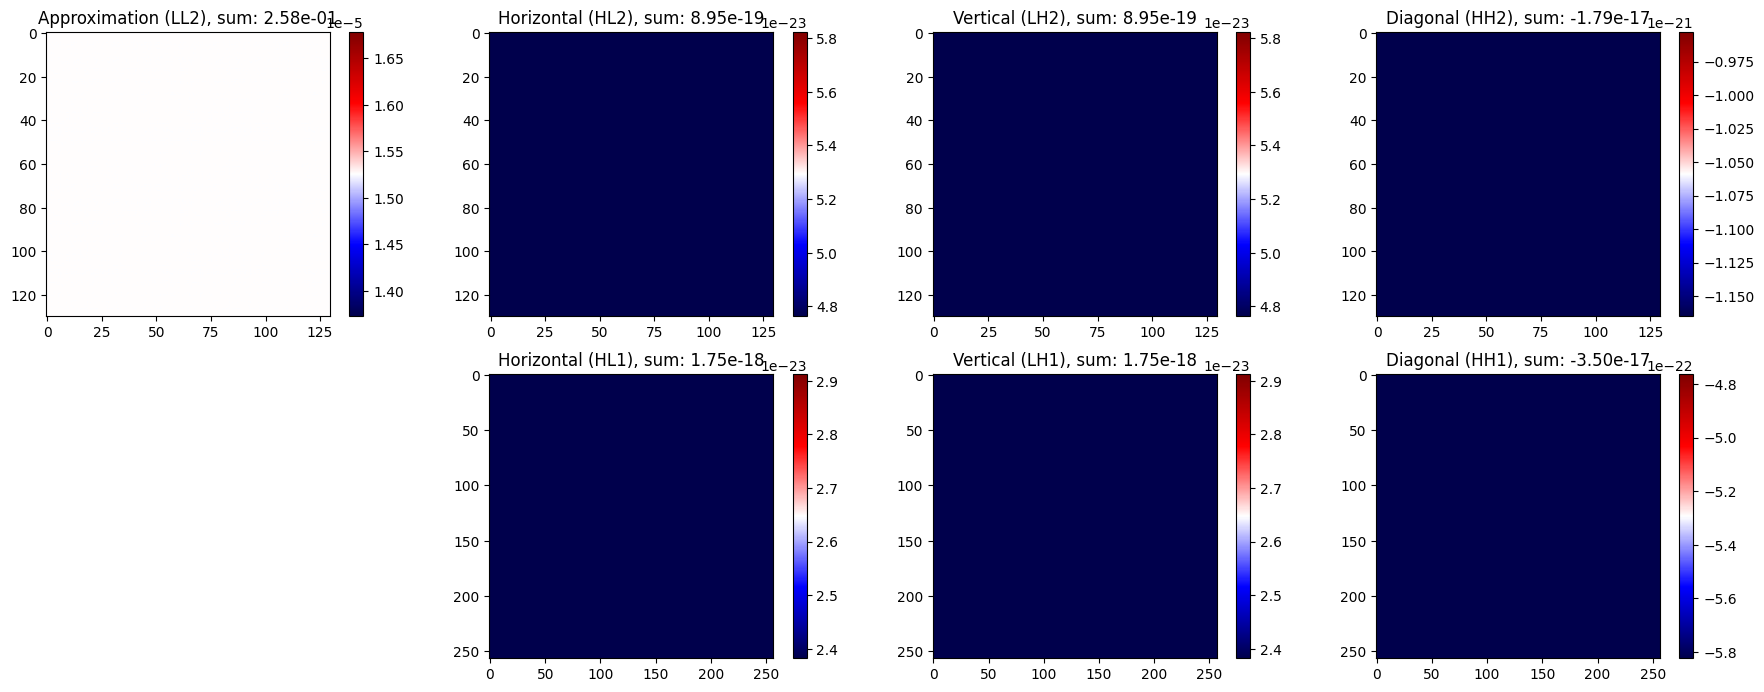

In [88]:
im = ascent() / ascent().sum()
wavelet = dorito.wavelets.Wavelets(im)

coeffs = np.hstack((wavelet.approx.flatten(), wavelet.values))
l2 = np.sqrt(np.linalg.norm(coeffs, ord=2))
print(l2)
level2_plot([wavelet.approx, *wavelet.build])


im2 = np.ones_like(im)
im2 /= im2.sum()
wavelet2 = dorito.wavelets.Wavelets(im2)

coeffs = np.hstack((wavelet2.approx.flatten(), wavelet2.values))
l2 = np.sqrt(np.linalg.norm(coeffs, ord=2))
print(l2)
level2_plot([wavelet2.approx, *wavelet2.build])